# Architecture Diagram — 1D-CNN Dual-Branch (V3-C)

Final model: **V3-C** — Optuna-tuned hyperparameters  
Conv filters: 27 / 15 / 96 · kernel=15 · stride=2  
Dense head: 3 × Dense(100, ReLU) + Dropout(0.296) → Dense(11, Softmax)

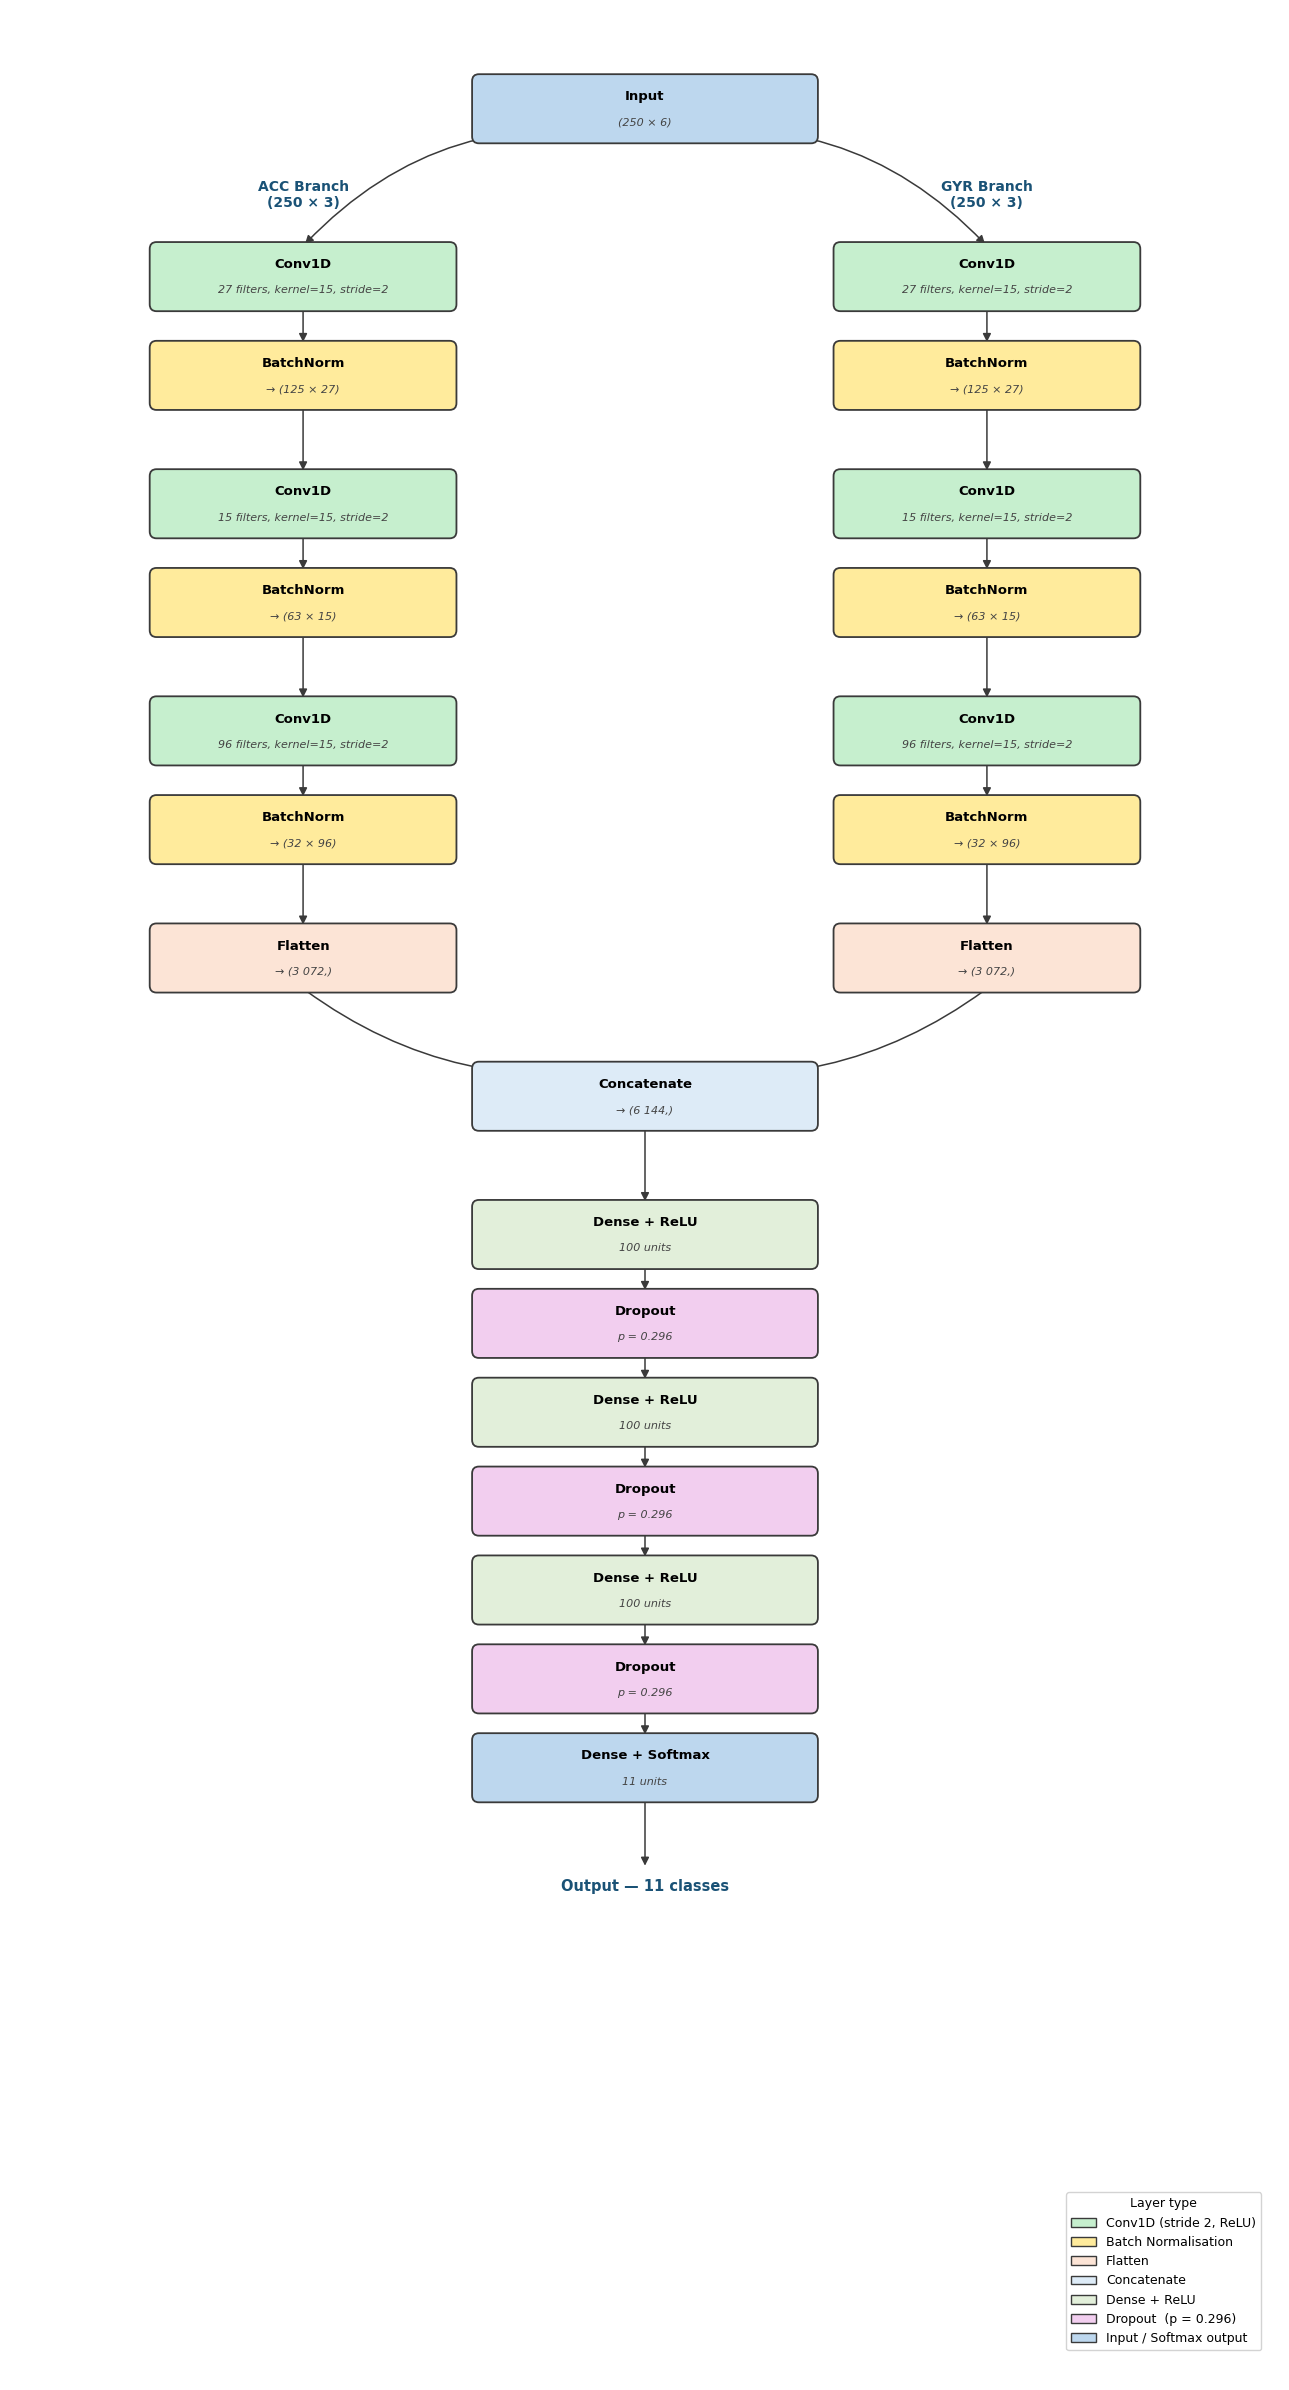

Saved: architecture_diagram.png


In [2]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch

# ── Colour palette ─────────────────────────────────────────────────────────────
C_IO     = "#BDD7EE"   # blue      – Input / Softmax output
C_CONV   = "#C6EFCE"   # green     – Conv1D
C_BN     = "#FFEB9C"   # amber     – BatchNorm
C_FLAT   = "#FCE4D6"   # salmon    – Flatten
C_CONCAT = "#DDEBF7"   # sky-blue  – Concatenate
C_DENSE  = "#E2EFDA"   # mint      – Dense
C_DROP   = "#F2CEEF"   # lilac     – Dropout
EDGE     = "#3A3A3A"

FW, FH = 13, 24
fig, ax = plt.subplots(figsize=(FW, FH))
ax.set_xlim(0, FW)
ax.set_ylim(0, FH)
ax.axis("off")
fig.patch.set_facecolor("white")

BH    = 0.56   # box height
BW_BR = 3.0    # branch box width
BW_CC = 3.4    # centre box width
XL    = 3.0    # left  branch centre-x
XR    = 10.0   # right branch centre-x
XC    = 6.5    # centre x

# ── Y coordinates (top → bottom = high y → low y) ─────────────────────────────
Y = dict(
    input  = 23.0,
    conv1  = 21.3,
    bn1    = 20.3,
    conv2  = 19.0,
    bn2    = 18.0,
    conv3  = 16.7,
    bn3    = 15.7,
    flat   = 14.4,
    concat = 13.0,
    fc1    = 11.6,
    drop1  = 10.7,
    fc2    =  9.8,
    drop2  =  8.9,
    fc3    =  8.0,
    drop3  =  7.1,
    clf    =  6.2,
    out    =  5.0,
)

# ── helpers ───────────────────────────────────────────────────────────────────
def draw_box(x, y, main, sub="", color="#E0E0E0", bw=BW_BR):
    rect = FancyBboxPatch(
        (x - bw / 2, y - BH / 2), bw, BH,
        boxstyle="round,pad=0.07",
        facecolor=color, edgecolor=EDGE, linewidth=1.3, zorder=3,
    )
    ax.add_patch(rect)
    if sub:
        ax.text(x, y + 0.12, main, ha="center", va="center",
                fontsize=9.5, fontweight="bold", zorder=4)
        ax.text(x, y - 0.14, sub, ha="center", va="center",
                fontsize=8, color="#444", style="italic", zorder=4)
    else:
        ax.text(x, y, main, ha="center", va="center",
                fontsize=9.5, fontweight="bold", zorder=4)


def varrow(x, y_from, y_to):
    ax.annotate(
        "", xy=(x, y_to + BH / 2 + 0.03),
        xytext=(x, y_from - BH / 2 - 0.03),
        arrowprops=dict(arrowstyle="-|>", color=EDGE, lw=1.1, mutation_scale=12),
        zorder=2,
    )


def curve_arrow(x1, y1, x2, y2, rad):
    ax.annotate(
        "", xy=(x2, y2 + BH / 2 + 0.03),
        xytext=(x1, y1 - BH / 2 - 0.03),
        arrowprops=dict(
            arrowstyle="-|>", color=EDGE, lw=1.1, mutation_scale=12,
            connectionstyle=f"arc3,rad={rad}",
        ),
        zorder=2,
    )


# ── Input ─────────────────────────────────────────────────────────────────────
draw_box(XC, Y["input"], "Input", "(250 × 6)", C_IO, bw=BW_CC)
curve_arrow(XC, Y["input"], XL, Y["conv1"], rad=0.28)
curve_arrow(XC, Y["input"], XR, Y["conv1"], rad=-0.28)

# Branch headers
for xb, lbl in [(XL, "ACC Branch\n(250 × 3)"), (XR, "GYR Branch\n(250 × 3)")]:
    ax.text(xb, Y["conv1"] + BH / 2 + 0.55, lbl,
            ha="center", va="center", fontsize=10,
            fontweight="bold", color="#1A5276")

# ── Both branches (identical structure) ───────────────────────────────────────
for x in (XL, XR):
    # Block 1 — 27 filters
    draw_box(x, Y["conv1"], "Conv1D",    "27 filters, kernel=15, stride=2", C_CONV)
    draw_box(x, Y["bn1"],   "BatchNorm", "→ (125 × 27)",                   C_BN)
    varrow(x, Y["conv1"], Y["bn1"])

    # Block 2 — 15 filters
    varrow(x, Y["bn1"], Y["conv2"])
    draw_box(x, Y["conv2"], "Conv1D",    "15 filters, kernel=15, stride=2", C_CONV)
    draw_box(x, Y["bn2"],   "BatchNorm", "→ (63 × 15)",                    C_BN)
    varrow(x, Y["conv2"], Y["bn2"])

    # Block 3 — 96 filters
    varrow(x, Y["bn2"], Y["conv3"])
    draw_box(x, Y["conv3"], "Conv1D",    "96 filters, kernel=15, stride=2", C_CONV)
    draw_box(x, Y["bn3"],   "BatchNorm", "→ (32 × 96)",                    C_BN)
    varrow(x, Y["conv3"], Y["bn3"])

    # Flatten
    varrow(x, Y["bn3"], Y["flat"])
    draw_box(x, Y["flat"], "Flatten", "→ (3 072,)", C_FLAT)

# ── Concatenate ───────────────────────────────────────────────────────────────
draw_box(XC, Y["concat"], "Concatenate", "→ (6 144,)", C_CONCAT, bw=BW_CC)
curve_arrow(XL, Y["flat"], XC, Y["concat"], rad=0.22)
curve_arrow(XR, Y["flat"], XC, Y["concat"], rad=-0.22)

# ── Dense Head with Dropout ───────────────────────────────────────────────────
varrow(XC, Y["concat"], Y["fc1"])
draw_box(XC, Y["fc1"],   "Dense + ReLU",      "100 units",        C_DENSE, bw=BW_CC)
varrow(XC, Y["fc1"],   Y["drop1"])
draw_box(XC, Y["drop1"], "Dropout",            "p = 0.296",        C_DROP,  bw=BW_CC)

varrow(XC, Y["drop1"], Y["fc2"])
draw_box(XC, Y["fc2"],   "Dense + ReLU",      "100 units",        C_DENSE, bw=BW_CC)
varrow(XC, Y["fc2"],   Y["drop2"])
draw_box(XC, Y["drop2"], "Dropout",            "p = 0.296",        C_DROP,  bw=BW_CC)

varrow(XC, Y["drop2"], Y["fc3"])
draw_box(XC, Y["fc3"],   "Dense + ReLU",      "100 units",        C_DENSE, bw=BW_CC)
varrow(XC, Y["fc3"],   Y["drop3"])
draw_box(XC, Y["drop3"], "Dropout",            "p = 0.296",        C_DROP,  bw=BW_CC)

varrow(XC, Y["drop3"], Y["clf"])
draw_box(XC, Y["clf"],   "Dense + Softmax",   "11 units",         C_IO,    bw=BW_CC)

# ── Output label ──────────────────────────────────────────────────────────────
ax.annotate(
    "", xy=(XC, Y["out"] + 0.18),
    xytext=(XC, Y["clf"] - BH / 2 - 0.03),
    arrowprops=dict(arrowstyle="-|>", color=EDGE, lw=1.1, mutation_scale=12),
    zorder=2,
)
ax.text(XC, Y["out"], "Output — 11 classes",
        ha="center", va="center", fontsize=10.5,
        fontweight="bold", color="#1A5276")

# ── Legend ────────────────────────────────────────────────────────────────────
legend_items = [
    mpatches.Patch(facecolor=C_CONV,   edgecolor=EDGE, label="Conv1D (stride 2, ReLU)"),
    mpatches.Patch(facecolor=C_BN,     edgecolor=EDGE, label="Batch Normalisation"),
    mpatches.Patch(facecolor=C_FLAT,   edgecolor=EDGE, label="Flatten"),
    mpatches.Patch(facecolor=C_CONCAT, edgecolor=EDGE, label="Concatenate"),
    mpatches.Patch(facecolor=C_DENSE,  edgecolor=EDGE, label="Dense + ReLU"),
    mpatches.Patch(facecolor=C_DROP,   edgecolor=EDGE, label="Dropout  (p = 0.296)"),
    mpatches.Patch(facecolor=C_IO,     edgecolor=EDGE, label="Input / Softmax output"),
]
ax.legend(
    handles=legend_items,
    loc="lower right", bbox_to_anchor=(0.99, 0.01),
    fontsize=9, framealpha=0.85, title="Layer type", title_fontsize=9,
)

plt.tight_layout()
plt.savefig("architecture_diagram.png", dpi=200, bbox_inches="tight",
            facecolor="white")
plt.show()
print("Saved: architecture_diagram.png")